# **ECOBICI** 🚴
Presento un analisis historico del desarrollo de las ecobicis (ciclovias)

Incorporación del primer conjunto de dataset-2024 para la exploración de columnas.



*   Usuarios ecobici
*   Recorridos realizados

# Modificamos los tipos de datos #recorridos

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta_archivo = '/content/drive/MyDrive/ecobici/recorridos_maestro_LIMPIO.csv'
df_ecobici = pd.read_csv(ruta_archivo, low_memory=False)
df_ecobici.head()

In [ ]:
# 1. Recuperar las fechas (de texto a formato fecha real)
columnas_fechas = ['fecha_origen_recorrido', 'fecha_destino_recorrido']
for col in columnas_fechas:
    df_ecobici[col] = pd.to_datetime(df_ecobici[col], errors='coerce')

print("✅ ¡Tipos de datos actualizados con éxito!")
df_ecobici.info()

✅ ¡Tipos de datos actualizados con éxito!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26373262 entries, 0 to 26373261
Data columns (total 9 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   duracion_recorrido       float64       
 1   fecha_origen_recorrido   datetime64[ns]
 2   id_estacion_origen       float64       
 3   nombre_estacion_origen   object        
 4   fecha_destino_recorrido  datetime64[ns]
 5   id_estacion_destino      float64       
 6   nombre_estacion_destino  object        
 7   id_usuario               int64         
 8   genero                   object        
dtypes: datetime64[ns](2), float64(3), int64(1), object(3)
memory usage: 1.8+ GB


In [ ]:
# 2. Recuperar los IDs (borrar los decimales .0 y pasarlos a texto puro)
columnas_id = ['id_usuario', 'id_estacion_origen', 'id_estacion_destino']
for col in columnas_id:
    # Lo pasamos a texto, borramos el ".0" y acomodamos los nulos
    df_ecobici[col] = df_ecobici[col].astype(str).str.replace('.0', '', regex=False).replace('nan', np.nan)

print("✅ ¡Tipos de datos actualizados con éxito!")
df_ecobici.info()

No se logro modificar los tipos de datos por que no logro ejecutarse por el gran tamaño.

Cargamos los datos localmentente desde "Símbolo del sistema" (cmd) en Windows.

Conectamos el entorno de SQL para cargarlos los datos localmente con autorización del servidor.
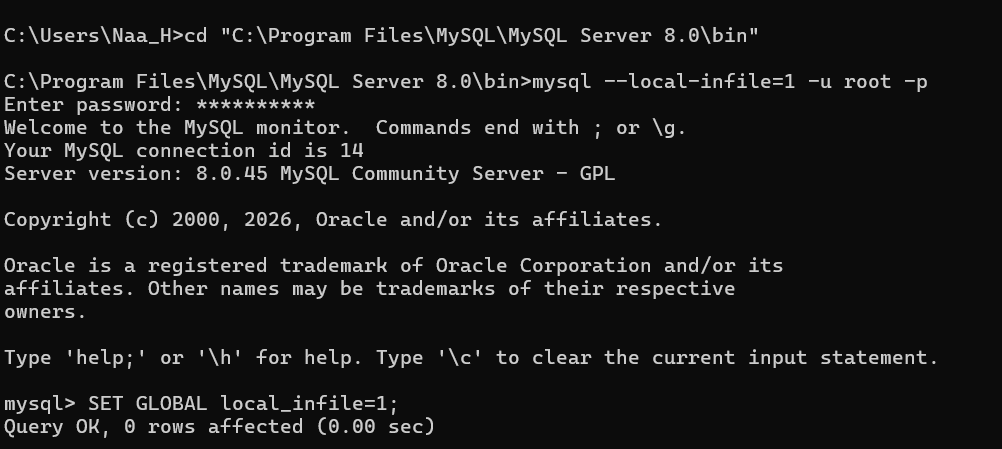

Una vez conectador al servidor de SQL realizamos la carga local y verificamos las primeras 5 filas.
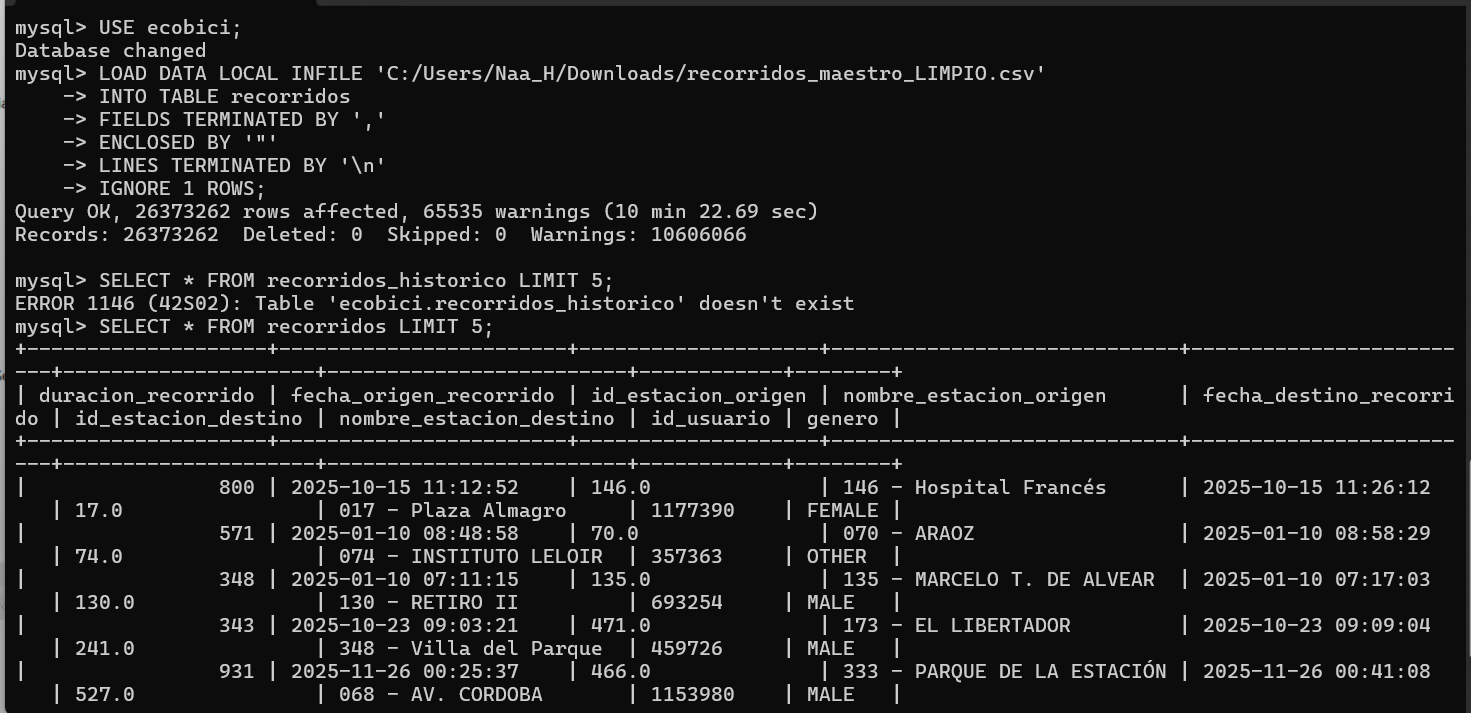

tipos de datos
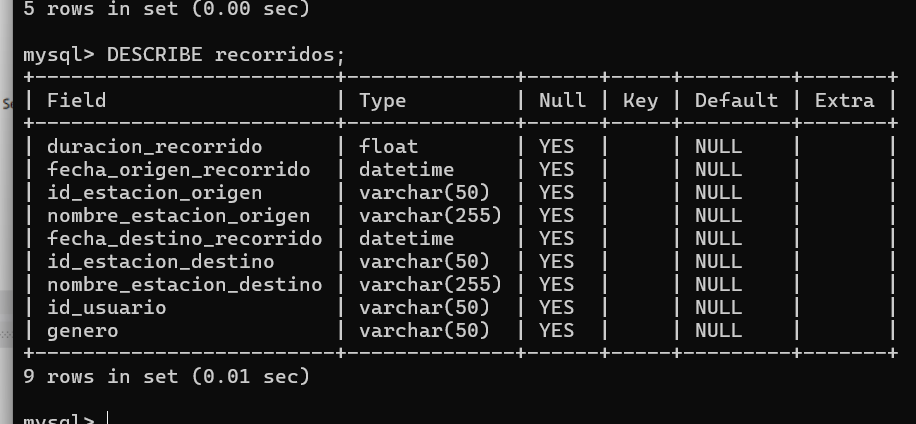

cargamos localmente el padron de usarios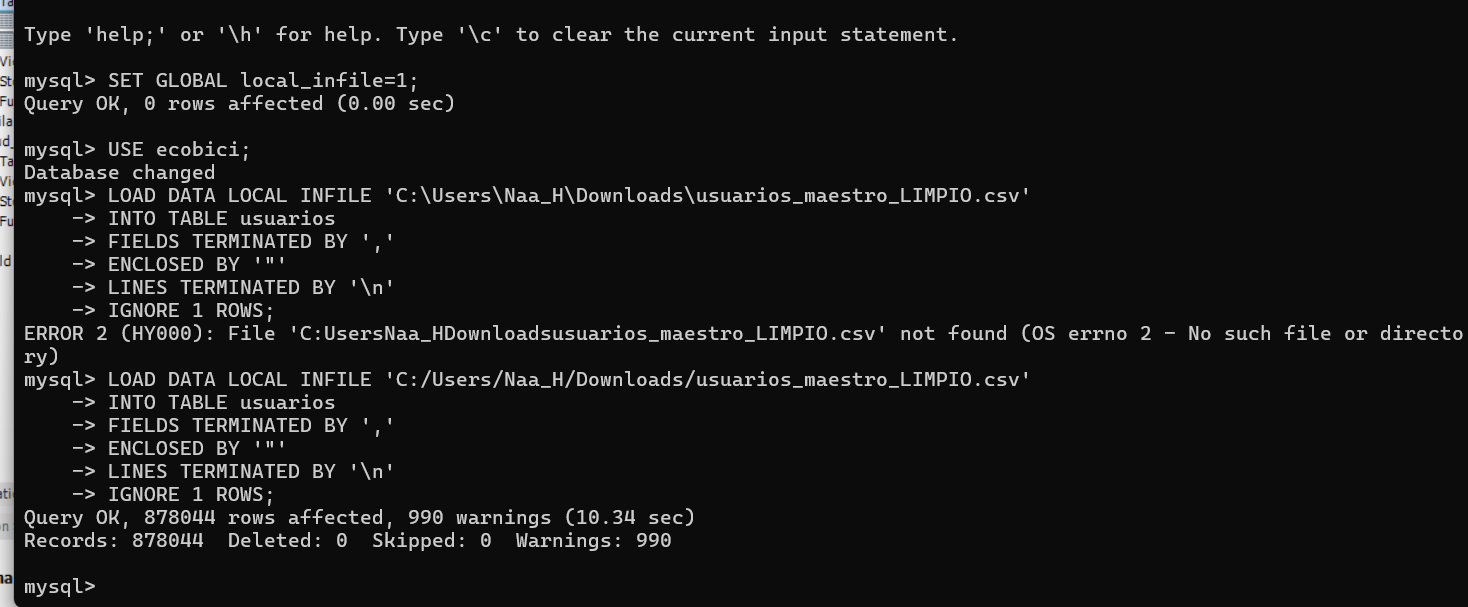

# **Union de tablas usuarios - recorridos**

Cuando hicimos la union nos dio error porque hay usuarios fantasmas que no aparecen en el padron.

* La base de usuarios es desde 2015 hasta 2025
* Los recorridos con id_usuario son del 2018 al 2025. Desde el 2010 hasta el 2017 los viajes no tienen id_usuario.
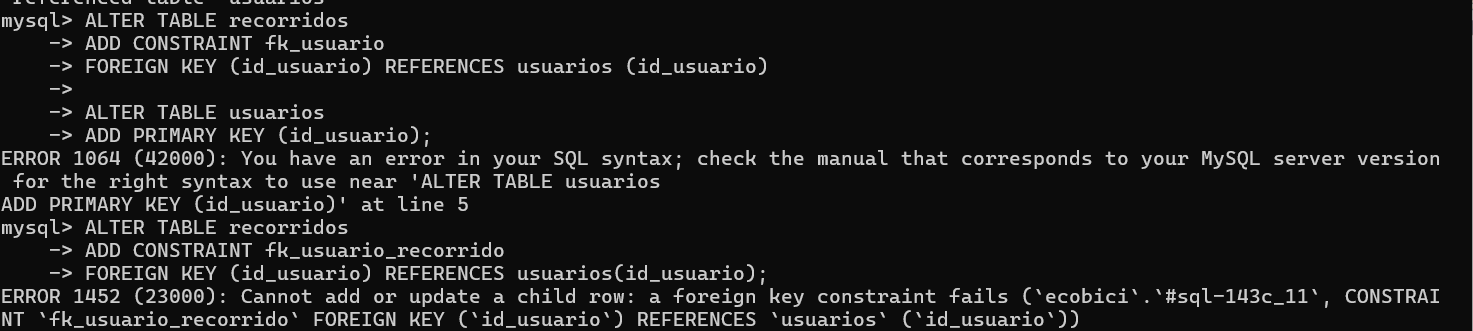

Tenemos 6647943 recorridos que no aparecen en el padron. Equivale al 25% de la población total de datos recolectados.

 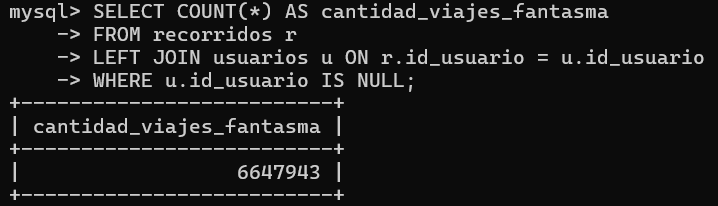

Problemas al momento de unir el foreing key

Tenemos 25% de usuarios que no aparecen en el padron
75% con los que si podemos unir las tablas

Como mi intención es hacer la union de tablas, vamos a solicitar y extraer los usuarios fantasmas para agregarlos al padron y no perder los recorridos historicos.

Solo contamos con id_usuario y genero, no tenemos información de fecha de alta o edad, se agregaran muchas celdas vacias pero que durante el analisis no generaria una distorción.

Revisamos el 25% y lo cargamos a la tabla usuarios para no perder esa información y lograr el foreing key.

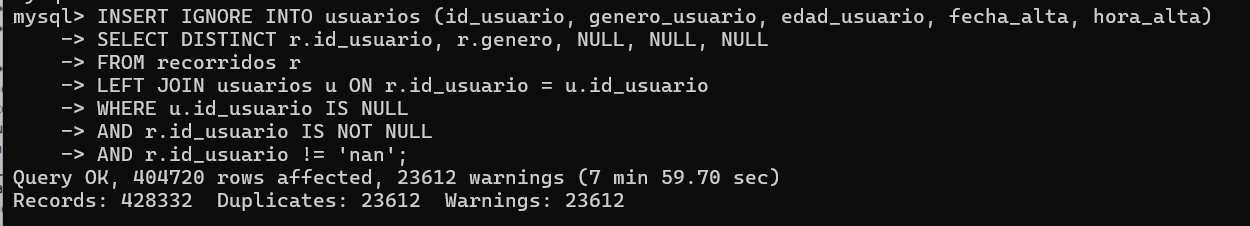

Establecemos la conexión entre las tablas usuarios y recorridos

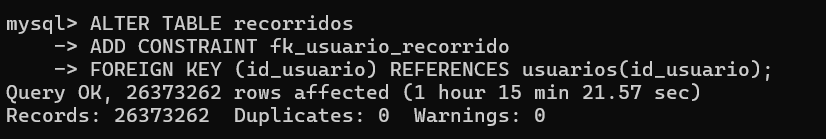

Union de 1:N

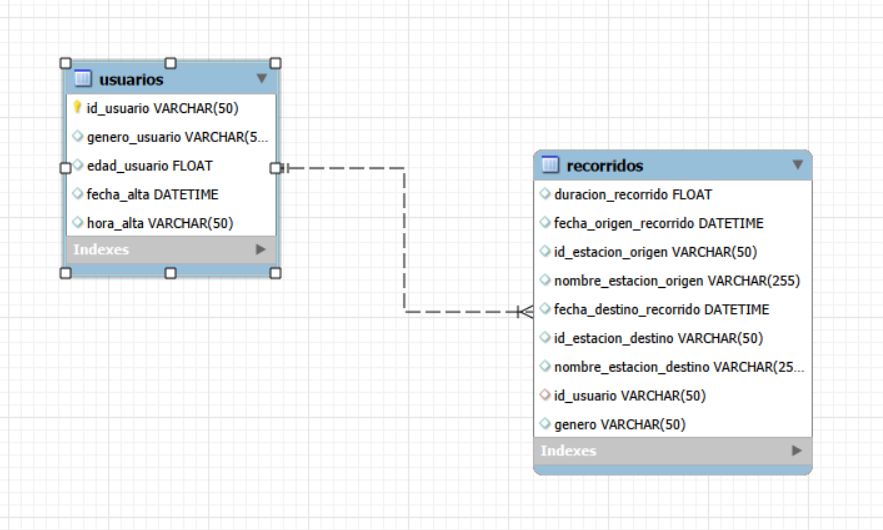